# Football Player Market Value Prediction

## Objective

The goal of this project is to build a machine learning model that predicts a football player's market value (`value_eur`) based on demographic, physical, technical, and performance-related features.

**Target variable:** `value_euro`

**Task type:** Regression

**Evaluation metrics:** MAE, RMSE, R²

# Data Loading

## Objective

The goal of this step is to load the dataset and verify that it has been imported correctly.


### Imports

Import the libraries needed for data manipulation, visualization, and building the machine-learning pipeline (pandas, numpy, matplotlib/seaborn, scikit-learn).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler,
                                   OneHotEncoder, OrdinalEncoder)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_regression

SEED = 42

### Load the dataset

Read the raw FIFA players CSV file into a pandas DataFrame.


In [ ]:
df = pd.read_csv("fifa_players.csv")

### First look at the data

Inspect the first and last rows, the shape, column names, data types, and a random sample to get a quick sense of what the dataset looks like.


In [ ]:
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [ ]:
df.tail()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17
17953,Júnior Brumado,José Francisco dos Santos Júnior,5/15/1999,19,190.50,79.8,ST,Brazil,59,75,...,53,67,20,53,49,52,45,23,31,21


In [ ]:
df.shape

(17954, 51)

In [ ]:
list(df.columns)

['name',
 'full_name',
 'birth_date',
 'age',
 'height_cm',
 'weight_kgs',
 'positions',
 'nationality',
 'overall_rating',
 'potential',
 'value_euro',
 'wage_euro',
 'preferred_foot',
 'international_reputation(1-5)',
 'weak_foot(1-5)',
 'skill_moves(1-5)',
 'body_type',
 'release_clause_euro',
 'national_team',
 'national_rating',
 'national_team_position',
 'national_jersey_number',
 'crossing',
 'finishing',
 'heading_accuracy',
 'short_passing',
 'volleys',
 'dribbling',
 'curve',
 'freekick_accuracy',
 'long_passing',
 'ball_control',
 'acceleration',
 'sprint_speed',
 'agility',
 'reactions',
 'balance',
 'shot_power',
 'jumping',
 'stamina',
 'strength',
 'long_shots',
 'aggression',
 'interceptions',
 'positioning',
 'vision',
 'penalties',
 'composure',
 'marking',
 'standing_tackle',
 'sliding_tackle']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [ ]:
df.describe()

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,1.769900e+04,17708.000000,17954.000000,17954.000000,17954.000000,...,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000
mean,25.565445,174.946921,75.301047,66.240169,71.430935,2.479280e+06,9902.134628,1.111674,2.945695,2.361034,...,46.852456,55.816531,46.657959,49.857302,53.406260,48.357302,58.680183,47.162861,47.733040,45.705915
std,4.705708,14.029449,7.083684,6.963730,6.131339,5.687014e+06,21995.593750,0.392168,0.663691,0.763223,...,19.429337,17.394047,20.754649,19.694311,14.156038,15.810844,11.625541,20.037346,21.674973,21.285812
min,17.000000,152.400000,49.900000,47.000000,48.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,3.000000,11.000000,3.000000,2.000000,10.000000,5.000000,12.000000,3.000000,2.000000,3.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,2.000000,...,32.000000,44.000000,26.000000,38.000000,44.000000,38.000000,51.000000,30.000000,27.000000,24.000000
50%,25.000000,175.260000,74.800000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,2.000000,...,51.000000,59.000000,52.000000,55.000000,55.000000,49.000000,60.000000,52.500000,55.000000,52.000000
75%,29.000000,185.420000,79.800000,71.000000,75.000000,2.100000e+06,9000.000000,1.000000,3.000000,3.000000,...,62.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.000000,64.000000,66.000000,64.000000
max,46.000000,205.740000,110.200000,94.000000,95.000000,1.105000e+08,565000.000000,5.000000,5.000000,5.000000,...,94.000000,95.000000,92.000000,95.000000,94.000000,92.000000,96.000000,94.000000,93.000000,90.000000


In [ ]:
df.sample(5, random_state=42)

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
9834,S. Davies,Steven Davies,12/29/1987,31,185.42,73.0,ST,England,64,64,...,64,69,38,66,61,66,67,31,44,34
5815,L. Ashby-Hammond,Luca Ashby-Hammond,3/25/2001,17,185.42,76.2,GK,England,56,76,...,9,14,8,4,32,41,38,9,14,10
4093,G. McEachran,George McEachran,8/30/2000,18,172.72,64.9,"CAM,CM",England,59,81,...,32,49,35,53,64,50,63,38,55,52
7476,Y. Goke,郷家 友太,6/10/1999,19,182.88,73.9,"CM,RM,LM",Japan,61,73,...,47,44,49,58,59,47,58,55,45,32
16455,Edercinho Sepa,Rodrigo Éder Serpa Conceição,2/29/1988,31,152.40,76.2,"CDM,CM",Brazil,74,74,...,77,66,66,70,63,70,69,81,76,68


# Exploratory Data Analysis (EDA)

## Objective

The goal of this step is to explore the dataset, understand its structure, identify patterns, and detect potential data quality issues before preprocessing.

### Shape and data types

Re-confirm the shape and data types before diving into the analysis.


In [ ]:
print(f'Shape: {df.shape}')
print()
print('Data types:')
print(df.dtypes.value_counts())
df.head(3)

Shape: (17954, 51)

Data types:
int64      35
object      9
float64     7
Name: count, dtype: int64


,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67


In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,17954.0,25.57,4.71,17.0,22.00,25.00,29.00,4.600000e+01
height_cm,17954.0,174.95,14.03,152.4,154.94,175.26,185.42,2.057400e+02
weight_kgs,17954.0,75.30,7.08,49.9,69.90,74.80,79.80,1.102000e+02
overall_rating,17954.0,66.24,6.96,47.0,62.00,66.00,71.00,9.400000e+01
potential,17954.0,71.43,6.13,48.0,67.00,71.00,75.00,9.500000e+01
value_euro,17699.0,2479280.19,5687013.85,10000.0,325000.00,700000.00,2100000.00,1.105000e+08
wage_euro,17708.0,9902.13,21995.59,1000.0,1000.00,3000.00,9000.00,5.650000e+05
international_reputation(1-5),17954.0,1.11,0.39,1.0,1.00,1.00,1.00,5.000000e+00
weak_foot(1-5),17954.0,2.95,0.66,1.0,3.00,3.00,3.00,5.000000e+00
skill_moves(1-5),17954.0,2.36,0.76,1.0,2.00,2.00,3.00,5.000000e+00


### Missing values

Identify which columns contain missing values and how severe the missingness is, so it can be handled properly during cleaning.


Columns with missing values: 7


,Missing Count,Missing %
national_jersey_number,17097,95.2
national_team_position,17097,95.2
national_rating,17097,95.2
national_team,17097,95.2
release_clause_euro,1837,10.2
value_euro,255,1.4
wage_euro,246,1.4


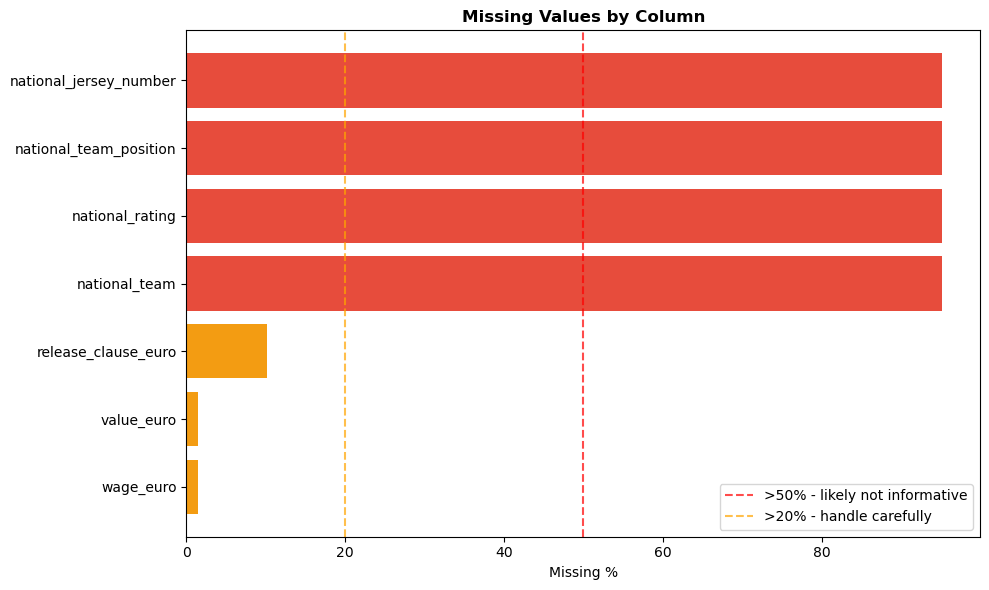

In [ ]:
# Missing values analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(f'Columns with missing values: {len(miss_df)}')
display(miss_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors_m = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#f39c12'
            for p in miss_df['Missing %']]
ax.barh(miss_df.index[::-1], miss_df['Missing %'][::-1], color=colors_m[::-1])
ax.axvline(50, color='red', ls='--', lw=1.5, alpha=0.7, label='>50% - likely not informative')
ax.axvline(20, color='orange', ls='--', lw=1.5, alpha=0.7, label='>20% - handle carefully')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

### Duplicate rows

Check whether the dataset contains duplicated rows.


In [ ]:
print('There are no duplicate data')
print('-'*28)
df.duplicated().sum()

There are no duplicate data
----------------------------


np.int64(0)

### Target variable distribution

Visualize the distribution of `value_euro` in its raw form and after a log transformation, since price-like targets are typically right-skewed.


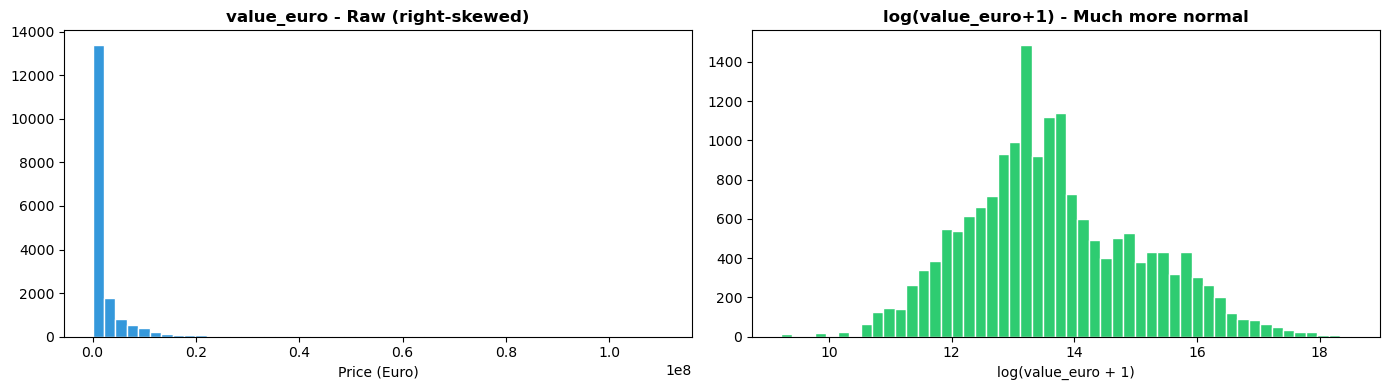

SalePrice skewness  (raw): 6.94
SalePrice skewness  (log): 0.37


In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['value_euro'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('value_euro - Raw (right-skewed)', fontweight='bold')
axes[0].set_xlabel('Price (Euro)')

axes[1].hist(np.log1p(df['value_euro']), bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('log(value_euro+1) - Much more normal', fontweight='bold')
axes[1].set_xlabel('log(value_euro + 1)')

plt.tight_layout(); plt.show()
print(f'SalePrice skewness  (raw): {df["value_euro"].skew():.2f}')
print(f'SalePrice skewness  (log): {np.log1p(df["value_euro"]).skew():.2f}')

### Correlation with the target

Compute the correlation of each numeric feature with `value_euro` and plot the strongest ones.


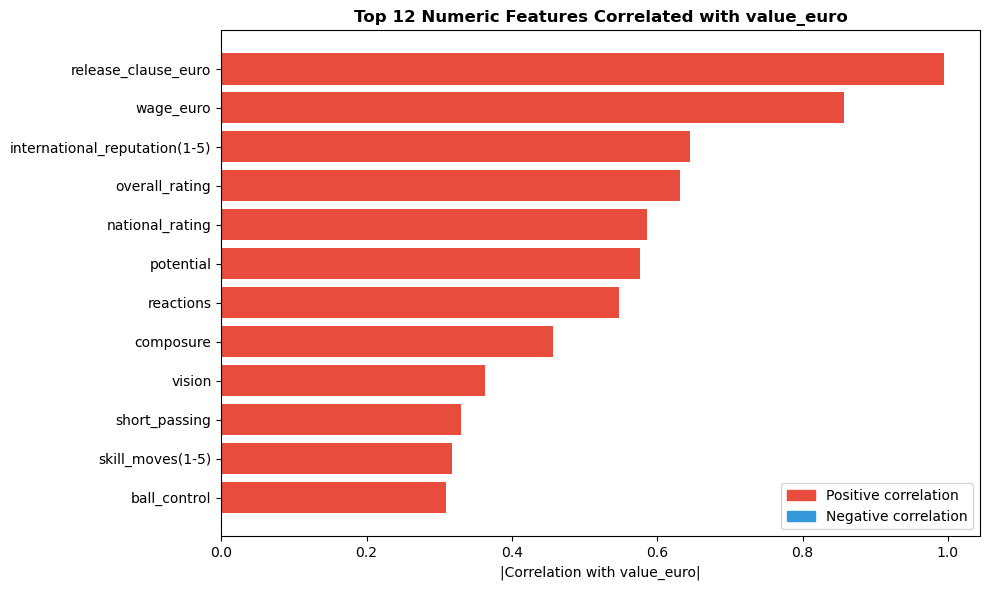

In [ ]:
# Numeric feature correlations with value_euro
import matplotlib.patches as mpatches

num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

top_corr = corr['value_euro'].drop('value_euro').abs().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 6))
actual_vals = corr['value_euro'].drop('value_euro').loc[top_corr.index]
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in actual_vals]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors_bar[::-1])
ax.set_xlabel('|Correlation with value_euro|')
ax.set_title('Top 12 Numeric Features Correlated with value_euro', fontweight='bold')
red_p  = mpatches.Patch(color='#e74c3c', label='Positive correlation')
blue_p = mpatches.Patch(color='#3498db', label='Negative correlation')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout(); plt.show()

### Correlation heatmap (top features)

Visualize how the top correlated numeric features relate to each other and to the target.


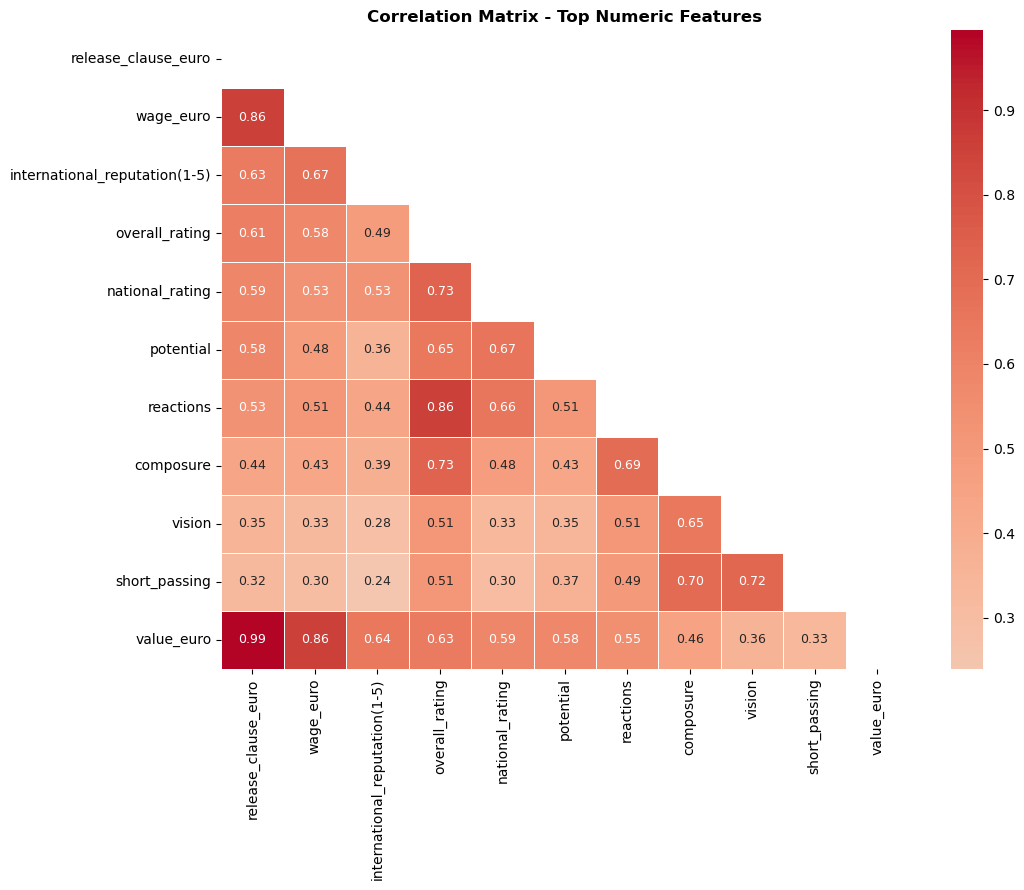

In [ ]:
# Correlation heatmap - top numeric features
top_num = top_corr.index[:10].tolist() + ['value_euro']
corr_sub = df[top_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix - Top Numeric Features', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

### Relationship between top features and the target

Scatter plots (with a fitted trend line) for the six features most correlated with `value_euro`.


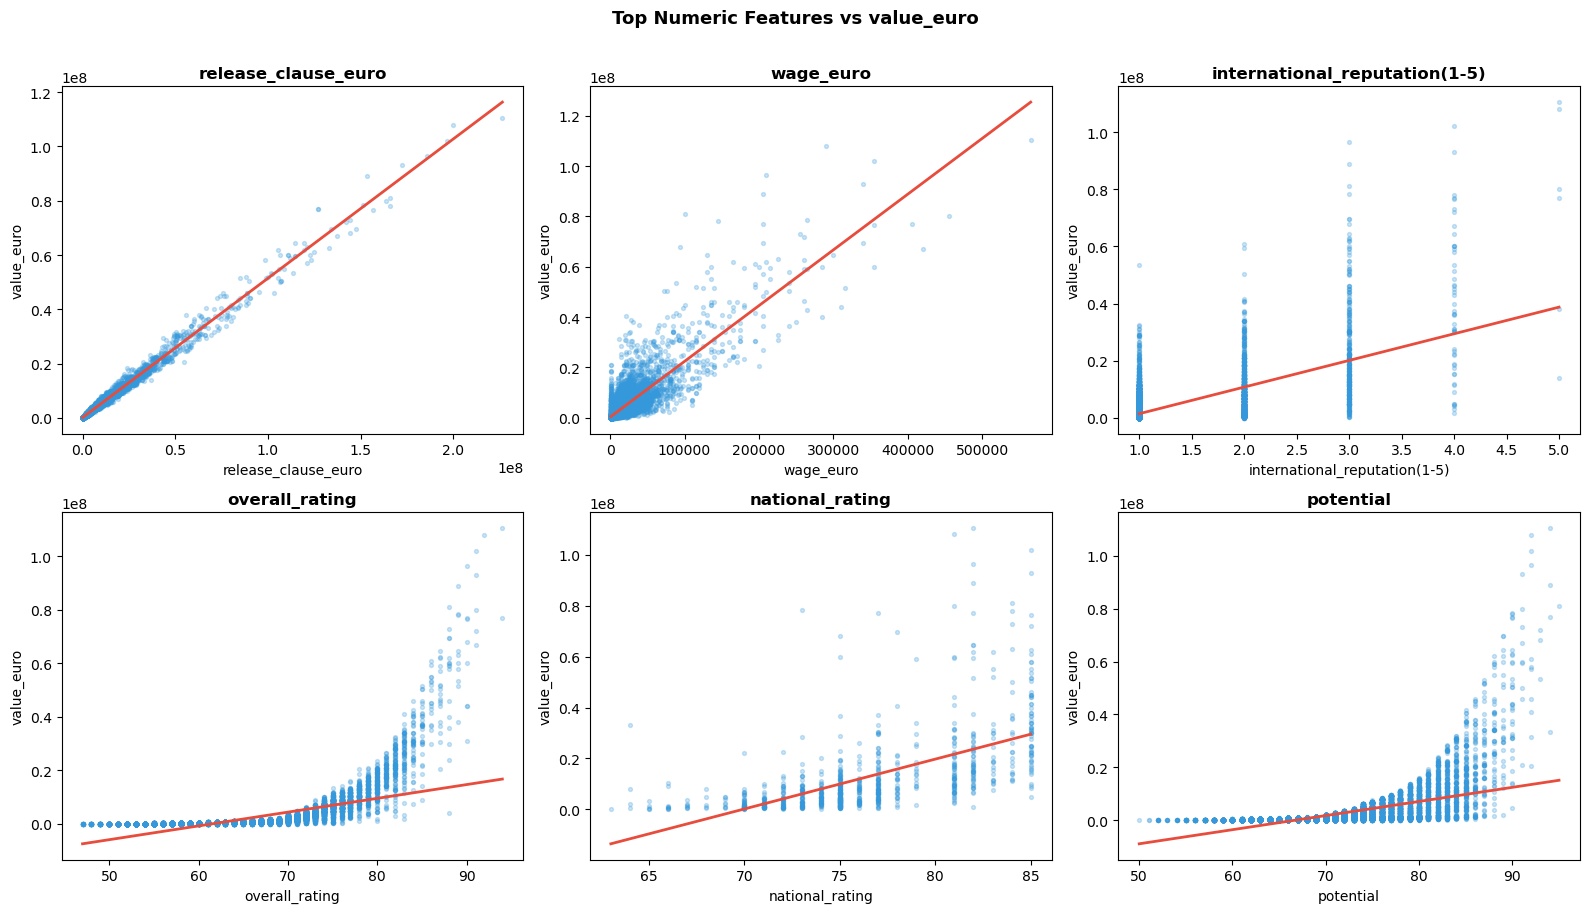

In [ ]:
# Scatter plots top 6 features vs value_euro
top_feats = top_corr.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), top_feats):
    temp = df[[feat, 'value_euro']].dropna()
    ax.scatter(temp[feat], temp['value_euro'], alpha=0.25, s=8, color='#3498db')
    m, b = np.polyfit(temp[feat], temp['value_euro'], 1)
    xl = np.linspace(temp[feat].min(), temp[feat].max(), 100)
    ax.plot(xl, m*xl+b, color='#e74c3c', lw=2)
    ax.set_xlabel(feat); ax.set_ylabel('value_euro')
    ax.set_title(feat, fontweight='bold')
plt.suptitle('Top Numeric Features vs value_euro', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### Categorical feature: `body_type`

Check the distribution of the `body_type` categorical feature.


In [ ]:
df["body_type"].value_counts()

body_type
Normal                 10393
Lean                    6468
Stocky                  1086
Messi                      1
Courtois                   1
PLAYER_BODY_TYPE_25        1
Akinfenwa                  1
Shaqiri                    1
Neymar                     1
C. Ronaldo                 1
Name: count, dtype: int64

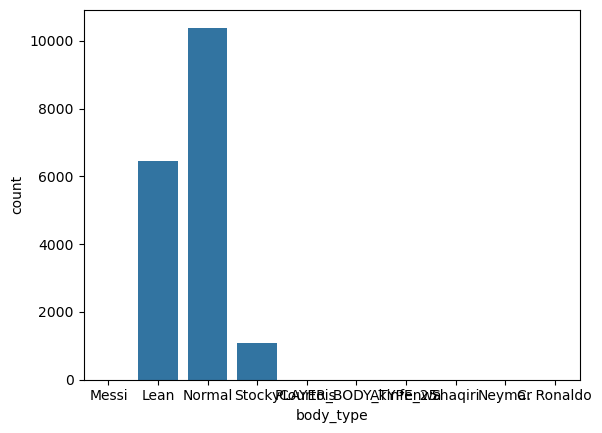

In [ ]:
sns.countplot(data=df, x="body_type")
plt.show()

### Most correlated feature pairs

Look at the pairs of numeric features (not necessarily involving the target) with the highest correlation, which helps spot redundant/multicollinear features.


C:\Users\User\AppData\Local\Temp\ipykernel_18688\2242694078.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


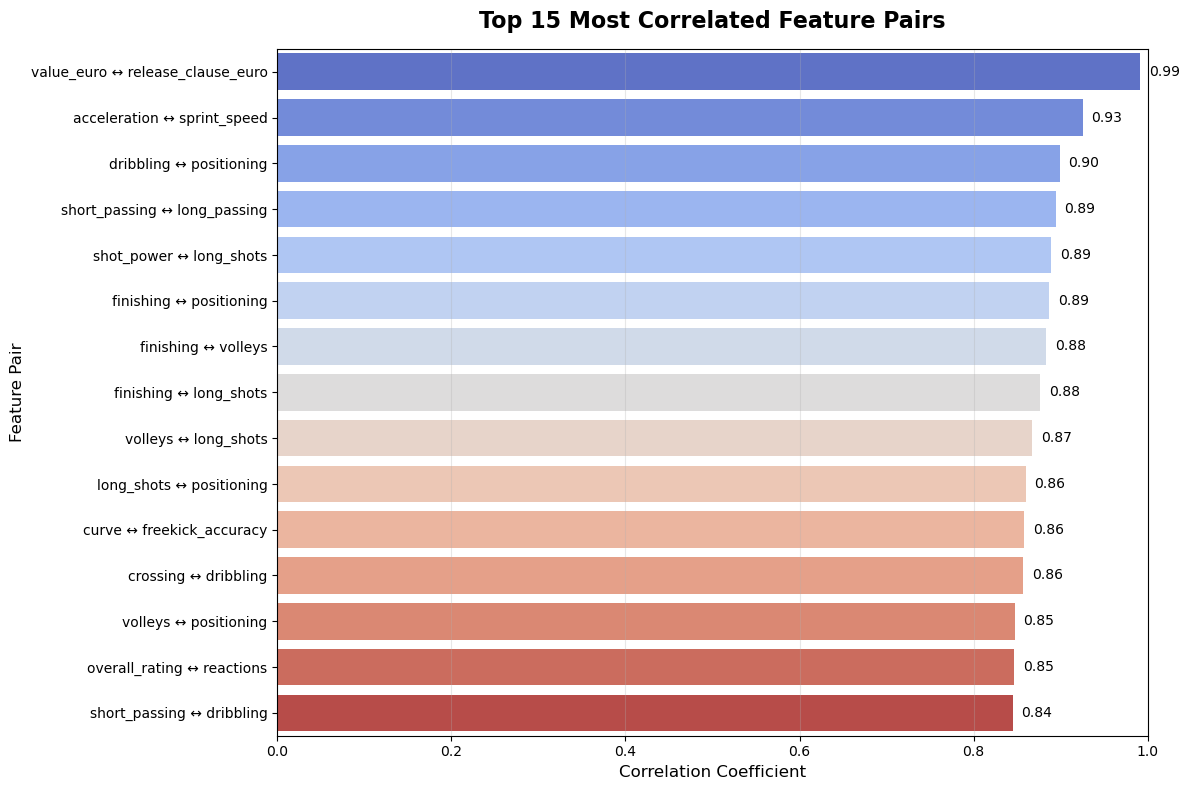

,Feature 1,Feature 2,Correlation
0,value_euro,release_clause_euro,0.991421
1,acceleration,sprint_speed,0.925121
2,dribbling,positioning,0.899099
3,short_passing,long_passing,0.894510
4,shot_power,long_shots,0.889359
5,finishing,positioning,0.886748
6,finishing,volleys,0.883341
7,finishing,long_shots,0.876564
8,volleys,long_shots,0.867379
9,long_shots,positioning,0.859876


In [ ]:

# Correlation matrix
corr = df.corr(numeric_only=True)

# Extract upper triangle (remove duplicates)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

# Top 15 correlated pairs
top15 = corr_pairs.head(15)

# Create dataframe for visualization
top15_df = (
    top15.reset_index()
    .rename(columns={
        "level_0": "Feature 1",
        "level_1": "Feature 2",
        0: "Correlation"
    })
)

top15_df["Feature Pair"] = (
    top15_df["Feature 1"] + " ↔ " + top15_df["Feature 2"]
)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top15_df,
    x="Correlation",
    y="Feature Pair",
    palette="coolwarm"
)

plt.title(
    "Top 15 Most Correlated Feature Pairs",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Feature Pair", fontsize=12)

plt.xlim(0, 1)

# Add values on bars
for i, value in enumerate(top15_df["Correlation"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# Display table
display(
    top15_df[
        ["Feature 1", "Feature 2", "Correlation"]
    ].reset_index(drop=True)
)

### Full correlation matrix

A heatmap of the correlation matrix across all numeric features.


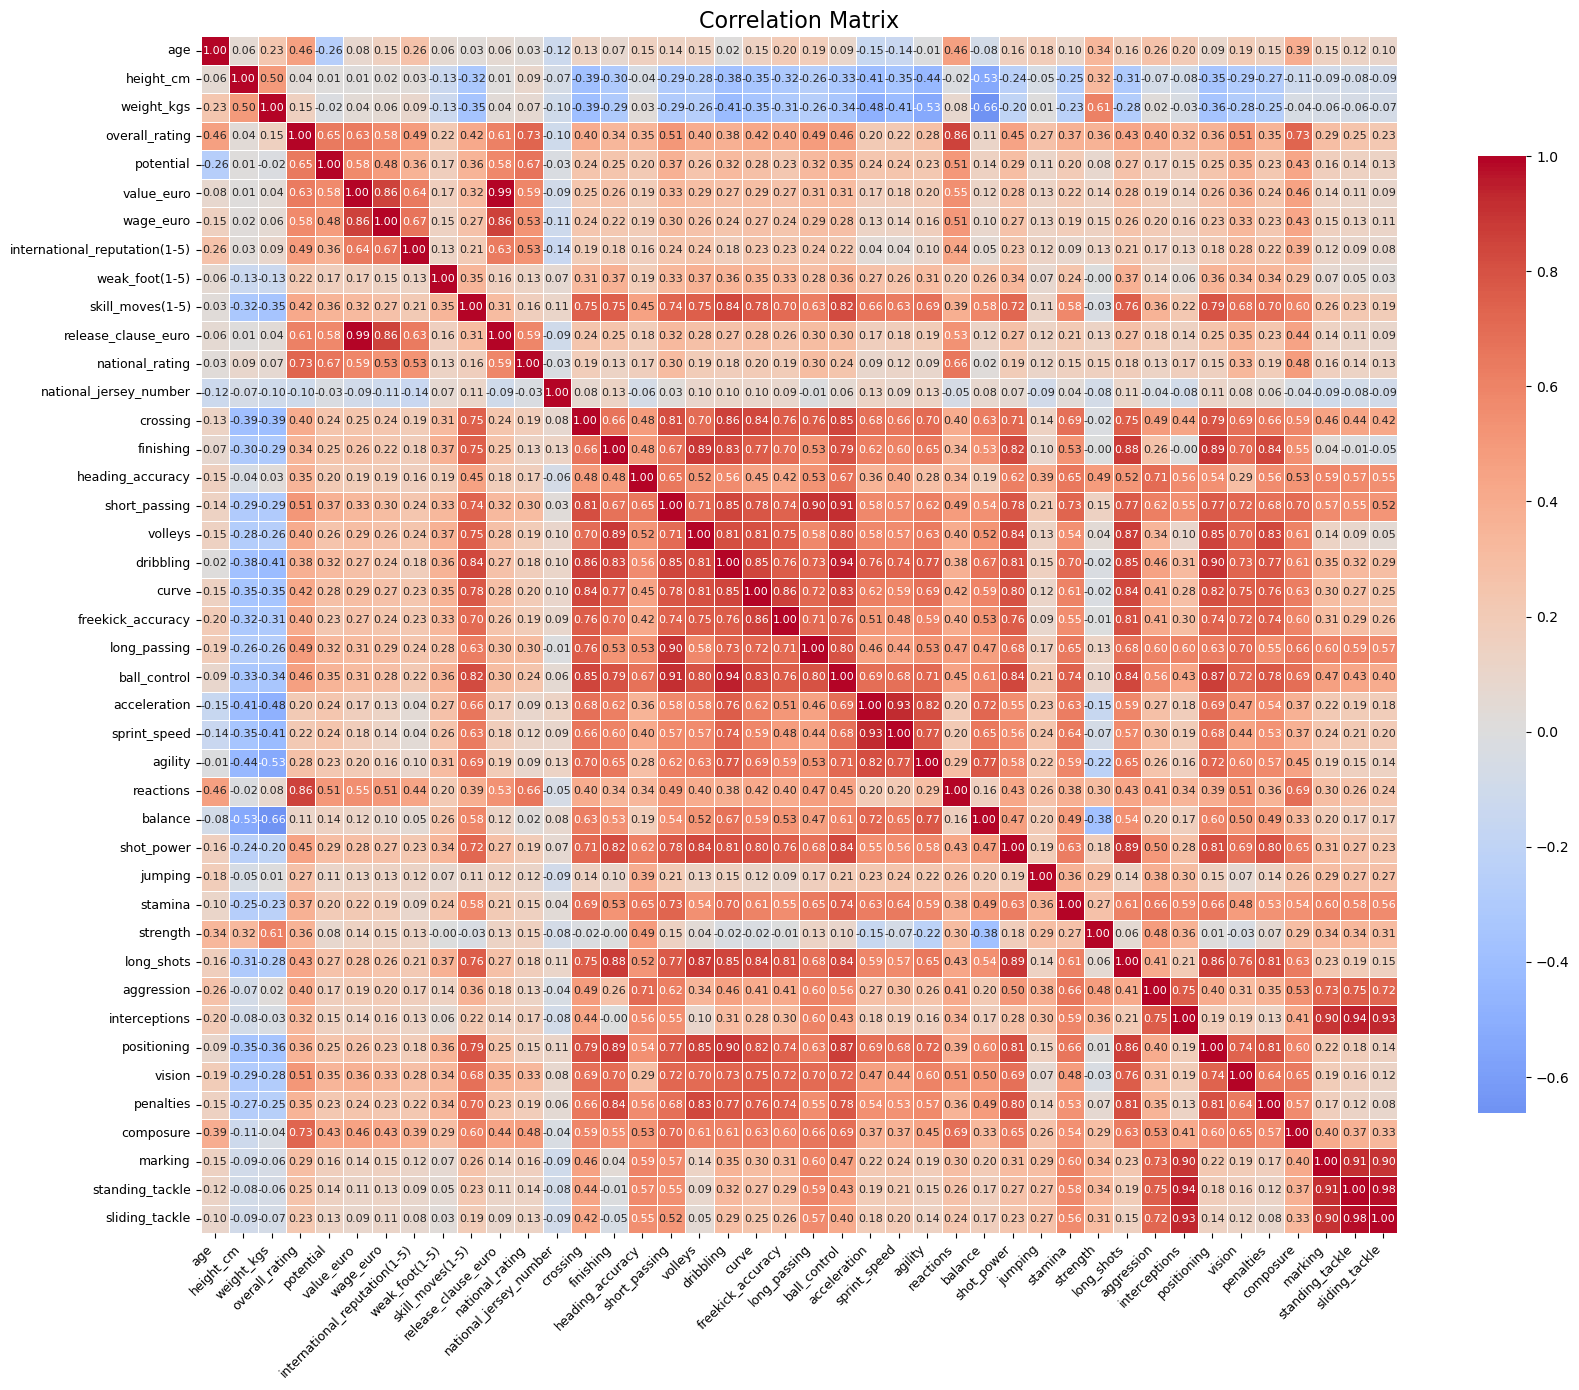

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

### Features most correlated with `value_euro`

List the numeric features whose correlation with the target exceeds 0.5.


In [ ]:
corr["value_euro"].sort_values(ascending=False)[corr["value_euro"] > 0.5]

value_euro                       1.000000
release_clause_euro              0.994318
wage_euro                        0.856466
international_reputation(1-5)    0.644610
overall_rating                   0.630928
national_rating                  0.586039
potential                        0.576341
reactions                        0.547615
Name: value_euro, dtype: float64

### Outlier check: skill features

Boxplots of all player skill ratings to visually inspect their spread and outliers.


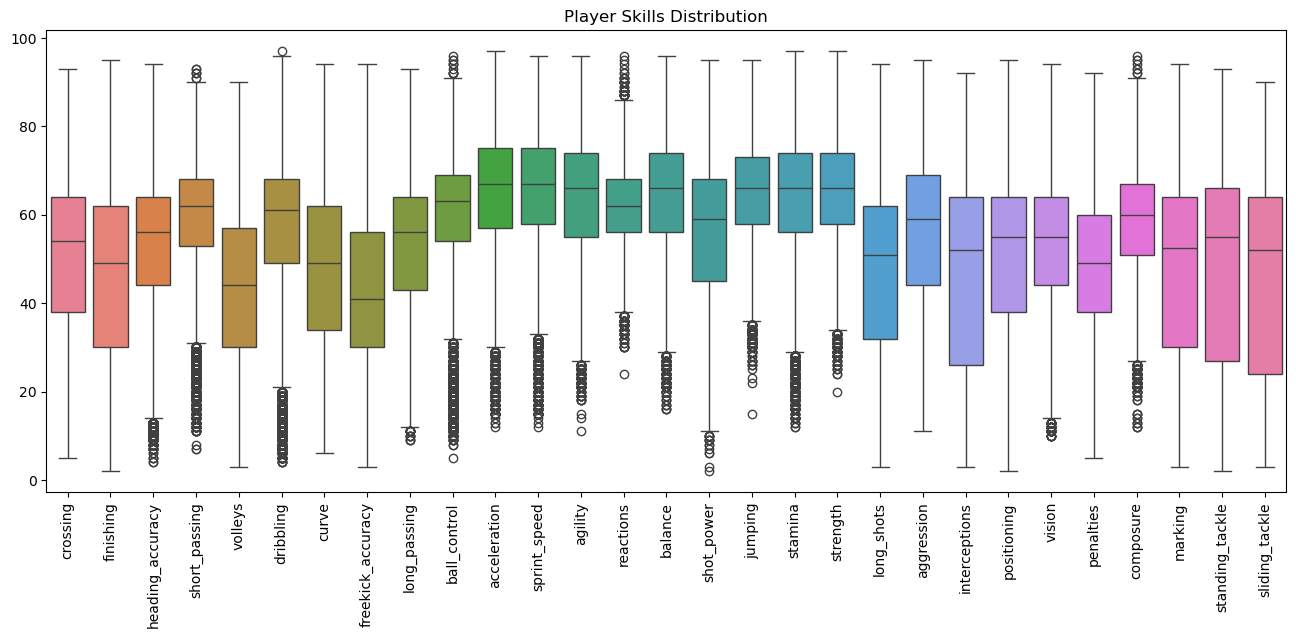

In [ ]:
skills = [
    'crossing',
    'finishing',
    'heading_accuracy',
    'short_passing',
    'volleys',
    'dribbling',
    'curve',
    'freekick_accuracy',
    'long_passing',
    'ball_control',
    'acceleration',
    'sprint_speed',
    'agility',
    'reactions',
    'balance',
    'shot_power',
    'jumping',
    'stamina',
    'strength',
    'long_shots',
    'aggression',
    'interceptions',
    'positioning',
    'vision',
    'penalties',
    'composure',
    'marking',
    'standing_tackle',
    'sliding_tackle'
]
plt.figure(figsize=(16,6))

sns.boxplot(
    data=df[skills]
)

plt.xticks(rotation=90)
plt.title("Player Skills Distribution")

plt.show()

### Outlier check: overall rating vs potential


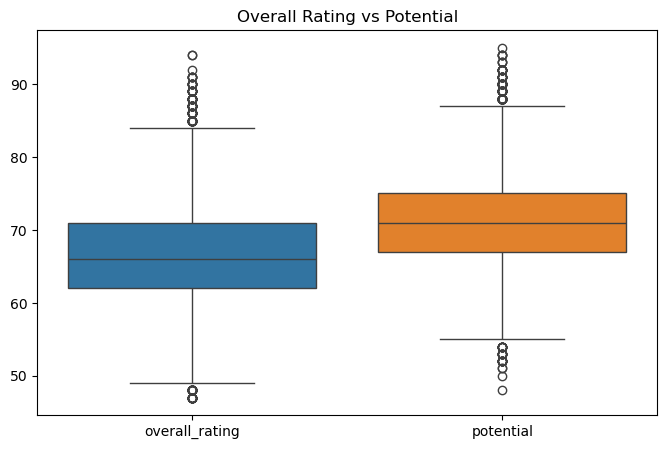

In [ ]:
ratings = [
    "overall_rating",
    "potential"
]


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[ratings]
)

plt.title("Overall Rating vs Potential")

plt.show()

### Outlier check: value and wage


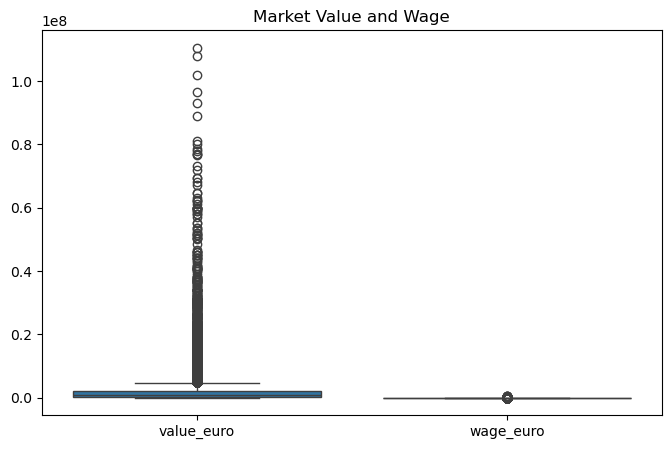

In [ ]:
money = [
    "value_euro",
    "wage_euro"
]


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[money]
)

plt.title("Market Value and Wage")

plt.show()

The target variable `value_euro` has a strong right-skewed distribution; applying a logarithmic transformation should be considered for modeling.

Some features contain missing values that require proper handling during preprocessing.

Several features show a high correlation with `value_euro` (for example, `release_clause_euro`, `wage_euro`, `international_reputation(1-5)`, `overall_rating`).

Outliers were identified among the most expensive players and on most player skills .

# Data Cleaning

## Objective

During the EDA stage, we identified potential issues in the dataset.

In this step, we will fix these problems and prepare the data for further processing.

### Column overview before cleaning

List all current columns before deciding what to drop.


In [ ]:
df.columns

Index(['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs',
       'positions', 'nationality', 'overall_rating', 'potential', 'value_euro',
       'wage_euro', 'preferred_foot', 'international_reputation(1-5)',
       'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type',
       'release_clause_euro', 'national_team', 'national_rating',
       'national_team_position', 'national_jersey_number', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'],
      dtype='object')

### Columns to drop

Define which columns will be removed and why (unique identifiers, redundant/leaky features, features with too many missing values, or highly correlated duplicates).


In [ ]:
# Columns to drop and the reason for each
drop_reasons = {
    'name'                   : 'Unique identifier',
    'full_name'              : 'Unique identifier',
    'birth_date'             : 'Because `age` already contains the same information.',
    'height_cm'              : 'Сontaines incorrect values.',
    'weight_kgs'             : 'Body-related metrics could not be calculated without height.',
    'wage_euro'              : 'high correlation with the target variable.',
    'preferred_foot'         : 'Has no significant impact on the target',
    'release_clause_euro'    : 'Has a very high correlation with the target and may cause data leakage.',
    'national_rating'        : 'More than 99% missing data',
    'national_jersey_number' : 'More than 99% missing data',
    'national_team'          : 'More than 99% missing data',
    'national_team_position' : 'More than 99% missing data',
    'ball_control'           : 'High correlation with dribling',
    'standing_tackle'        : 'High correlation with interceptions',
    'sliding_tackle'         : 'High correlation with interceptions',
    'marking'                : 'High correlation with interceptions',
}


print('Columns to be dropped before pipeline:')
print(f'{"-"*100}')
for col, reason in drop_reasons.items():
    col_upper = col if col in df.columns else col
    print(f'  {col:<22} -> {reason}')
print(f'{"-"*100}')
print(f'Total: {len(drop_reasons)} columns dropped')
print(f'Remaining: {df.shape[1] - len(drop_reasons) - 1} features (excluding value_euro)')

Columns to be dropped before pipeline:
----------------------------------------------------------------------------------------------------
  name                   -> Unique identifier
  full_name              -> Unique identifier
  birth_date             -> Because `age` already contains the same information.
  height_cm              -> Сontaines incorrect values.
  weight_kgs             -> Body-related metrics could not be calculated without height.
  wage_euro              -> high correlation with the target variable.
  preferred_foot         -> Has no significant impact on the target
  release_clause_euro    -> Has a very high correlation with the target and may cause data leakage.
  national_rating        -> More than 99% missing data
  national_jersey_number -> More than 99% missing data
  national_team          -> More than 99% missing data
  national_team_position -> More than 99% missing data
  ball_control           -> High correlation with dribling
  standing_tackle       

### Apply the drops

Actually remove the columns identified above from the DataFrame.


In [ ]:
# Apply drops
cols_to_drop = [c for c in drop_reasons.keys() if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)
print(f'Before drop: {df.shape[1]} columns')
print(f'After drop : {df_clean.shape[1]} columns')
print(f'Dropped    : {len(cols_to_drop)} columns')
print(f'Remaining features (excl target): {df_clean.shape[1] - 1}')

Before drop: 51 columns
After drop : 35 columns
Dropped    : 16 columns
Remaining features (excl target): 34


### Feature importance check

Use `SelectKBest` (F-statistic) on the numeric features to see which ones have the strongest linear relationship with the (log-transformed) target.


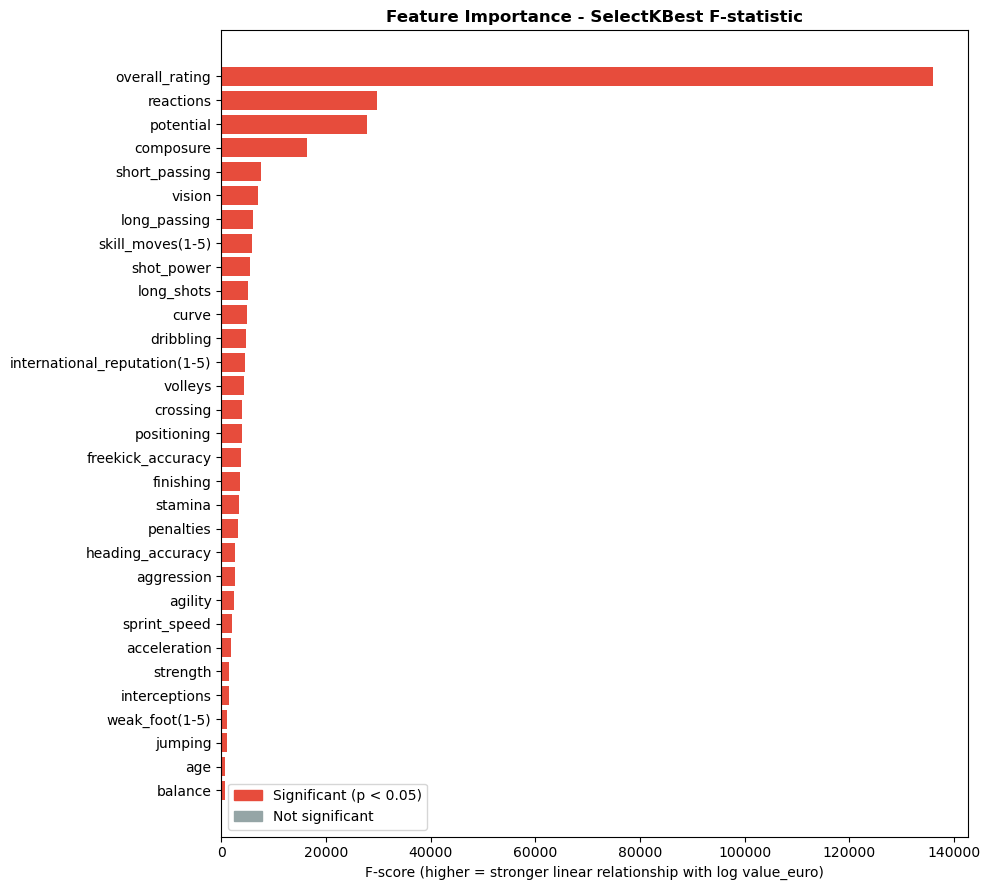

,Feature,F-score,p-value
0,overall_rating,135935.287863,0.0
1,reactions,29744.650763,0.0
2,potential,27784.528280,0.0
3,composure,16463.816598,0.0
4,short_passing,7619.305445,0.0
5,vision,7042.287627,0.0
6,long_passing,6031.048070,0.0
7,skill_moves(1-5),5793.053187,0.0
8,shot_power,5590.450361,0.0
9,long_shots,5089.054803,0.0


In [ ]:
# SelectKBest on numeric features
from sklearn.feature_selection import SelectKBest, f_regression

num_features_sel = [c for c in df_clean.select_dtypes(include=np.number).columns
                    if c != 'value_euro']
df_sel = df_clean[num_features_sel + ['value_euro']].dropna()
X_fs = df_sel[num_features_sel].values
y_fs = np.log1p(df_sel['value_euro'].values)

selector = SelectKBest(score_func=f_regression, k='all')

selector.fit(X_fs, y_fs)
scores_df = pd.DataFrame({
    'Feature': num_features_sel,
    'F-score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-score', ascending=False)



fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in scores_df['p-value']]
ax.barh(scores_df['Feature'][::-1], scores_df['F-score'][::-1], color=bar_colors[::-1])
ax.set_xlabel('F-score (higher = stronger linear relationship with log value_euro)')
ax.set_title('Feature Importance - SelectKBest F-statistic', fontweight='bold')
red_p  = mpatches.Patch(color='#e74c3c', label='Significant (p < 0.05)')
gray_p = mpatches.Patch(color='#95a5a6', label='Not significant')
ax.legend(handles=[red_p, gray_p])
plt.tight_layout(); plt.show()
display(scores_df.head(15).reset_index(drop=True))

### Outlier removal (IQR method)

Remove outliers from a few key numeric columns using the interquartile range (IQR) rule.


In [ ]:
print(df.shape)
for col in ['overall_rating', 'potential', 'long_passing', 'vision']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        df[col].between(lower, upper)
    ]

print(df.shape)

(17954, 51)
(17623, 51)


### Drop rows with a missing target

Any row without a `value_euro` value cannot be used for training, so those rows are dropped.


In [ ]:
df = df.dropna(
    subset=["value_euro"]
)

### Verify remaining missing values

Confirm what missing values (if any) remain after cleaning.


In [ ]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

national_jersey_number    16613
national_team_position    16613
national_rating           16613
national_team             16613
release_clause_euro        1573
dtype: int64

### Post-cleaning summary statistics


In [ ]:
df.describe()

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure
count,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,1.737500e+04,17375.000000,17375.000000,17375.000000,17375.000000,...,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000,17375.000000
mean,25.532777,174.861933,75.256645,66.126849,71.343309,2.112172e+06,8640.230216,1.096863,2.944576,2.362302,...,64.995108,63.230158,65.177209,46.914935,55.919309,46.724950,49.957755,53.453122,48.392345,58.590906
std,4.684467,14.038078,7.069870,6.666868,5.864030,3.710562e+06,14836.498260,0.345337,0.660589,0.750822,...,11.682912,15.730650,12.507535,19.197735,17.252312,20.635613,19.433657,13.785760,15.619148,11.359510
min,17.000000,152.400000,49.900000,49.000000,55.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,15.000000,12.000000,20.000000,3.000000,11.000000,3.000000,2.000000,14.000000,5.000000,12.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,2.000000,...,58.000000,56.000000,58.000000,32.000000,44.000000,26.000000,39.000000,44.000000,39.000000,51.000000
50%,25.000000,175.260000,74.800000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,2.000000,...,66.000000,66.000000,66.000000,51.000000,59.000000,52.000000,55.000000,55.000000,49.000000,60.000000
75%,29.000000,185.420000,79.800000,71.000000,75.000000,2.000000e+06,9000.000000,1.000000,3.000000,3.000000,...,73.000000,74.000000,74.000000,62.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.000000
max,46.000000,205.740000,110.200000,84.000000,87.000000,4.000000e+07,205000.000000,4.000000,5.000000,5.000000,...,94.000000,96.000000,97.000000,90.000000,95.000000,90.000000,90.000000,90.000000,92.000000,92.000000


### Post-cleaning shape


In [ ]:
df.shape

(17375, 36)

## Data Cleaning Summary

During the data cleaning process, several data quality issues were addressed.

The following steps were performed:

- Missing values were handled depending on the feature type.
- Irrelevant columns were removed.

After cleaning, the dataset became more consistent

# Feature Engineering

## Objective

In the previous steps, we:

- Defined the problem.
- Loaded the dataset.
- Explored the data.
- Cleaned data quality issues.

Now, we create new features that can help the machine learning model better understand hidden patterns and relationships in the data.

### New feature: `potential_gap`

Create a feature representing the gap between a player's potential and their current overall rating.


In [ ]:
df["potential_gap"] = df["potential"] - df["overall_rating"]

### New feature: `player_level`

Bin players into level categories (elite / high / average / low) based on their overall rating.


In [ ]:
def player_level(rating):
    if rating >= 85:
        return "elite"
    elif rating >= 75:
        return "high"
    elif rating >= 65:
        return "average"
    else:
        return "low"


df["player_level"] = df["overall_rating"].apply(player_level)

### Verify new features

Check that the newly engineered features were added correctly.


In [ ]:
df.head()

,age,positions,nationality,overall_rating,potential,value_euro,preferred_foot,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,potential_gap,player_level
33,25,"CAM,RW",Morocco,84,86,38000000.0,Left,3,2,4,...,59,76,72,62,76,88,72,83,2,high
36,23,ST,Germany,84,87,40000000.0,Right,3,4,3,...,64,70,63,37,85,61,72,74,3,high
39,26,LB,Brazil,84,86,31000000.0,Left,3,2,3,...,68,75,78,80,76,74,73,80,2,high
47,27,CM,Italy,83,84,30000000.0,Right,2,3,3,...,66,62,79,76,68,87,84,79,1,high
48,29,"RM,RW",Bosnia Herzegovina,83,83,26000000.0,Right,2,4,4,...,58,77,47,52,83,77,75,82,0,high


In [ ]:
df.shape

(17699, 46)

### Alternative pipeline experiment: train/test split

This section builds an alternative, more elaborate pipeline (with a custom low-correlation dropper and explicit ordinal/one-hot handling) as an additional experiment. Split the data into train/test sets and drop known problematic columns beforehand.


In [ ]:
TARGET = 'value_euro'
y_full = np.log1p(df[TARGET].values)
X_full = df.drop(columns=[TARGET])

# Columns to drop BEFORE pipeline (no threshold logic, just known bad columns)
COLS_TO_DROP = [
    'name',
    'full_name',
    'birth_date',
    'height_cm',
    'weight_kgs',
    'wage_euro',
    'preferred_foot',
    'release_clause_euro',
    'national_rating',
    'national_jersey_number',
    'national_team',
    'national_team_position',
    'ball_control',
    'standing_tackle',
    'sliding_tackle',
    'marking',
    'overall_rating',
    'potential'
]
X_full = X_full.drop(columns=[c for c in COLS_TO_DROP if c in X_full.columns])

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (13900, 32)  |  Test: (3475, 32)


### Custom transformer: low-correlation dropper

A custom scikit-learn transformer that drops numeric features whose correlation with the target falls below a threshold.


In [ ]:
# ── Custom Transformer: Low-Correlation Dropper (used inside pipeline) ────────
class LowCorrDropper(BaseEstimator, TransformerMixin):
    """
    Drops numeric features whose absolute Pearson correlation
    with the target is below `threshold`.
    Handles missing values before computing correlation.
    """
    def __init__(self, threshold=0.05): self.threshold = threshold
    def fit(self, X, y):
        df_ = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce')
        y_s = pd.Series(y)
        self.cols_to_keep_ = [
            c for c in df_.columns
            if abs(df_[c].fillna(df_[c].median()).corr(y_s)) >= self.threshold
        ]
        return self
    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_[self.cols_to_keep_]
    def get_feature_names_out(self, input_features=None):
        return np.array(self.cols_to_keep_)

print('Custom transformers ready.')

Custom transformers ready.


### Define feature groups

Group the remaining columns into numeric, ordinal (quality scores with a natural order), and one-hot (nominal categorical) features for preprocessing.


In [ ]:
# Quality columns with known ordinal order
ORDINAL_COLS = [
    "international_reputation(1-5)",
    "weak_foot(1-5)",
    "skill_moves(1-5)"
]

OHE_COLS = [
    "positions",
    "nationality",
    "body_type"
]

NUM_COLS = [
    "age",
    # "overall_rating",
    # "potential",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "freekick_accuracy",
    "long_passing",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "positioning",
    "vision",
    "penalties",
    "composure"
]

print(f'Numeric cols        : {len(NUM_COLS)}')
print(f'Ordinal quality cols: {len(ORDINAL_COLS)}')
print(f'One-Hot cols        : {len(OHE_COLS)}')

Numeric cols        : 26
Ordinal quality cols: 3
One-Hot cols        : 3


### Build preprocessing sub-pipelines

Create separate preprocessing pipelines for numeric, ordinal, and one-hot features, then combine them with a `ColumnTransformer`.


In [ ]:
# ── Sub-pipelines ─────────────────────────────────────────────────────────────

# Numeric: impute with median, then scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    )
])

# One-Hot: impute with mode, then encode
ohe_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num',      numeric_transformer,    NUM_COLS),
    ('ord',      ordinal_transformer,    ORDINAL_COLS),
    ('ohe',      ohe_transformer,        OHE_COLS),
], remainder='drop')

print('Preprocessor defined.')

Preprocessor defined.


### Fit the full pipeline

Combine the preprocessor with a Linear Regression model and fit it on the training data.


In [ ]:
# ── Full pipeline: Standardize -> Preprocess -> Model ────────────────────────

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression()),

    # ── Uncomment to try regularized models ──────────────────────────────────
    # ('model', Ridge(alpha=10)),
    # ('model', Lasso(alpha=0.001, max_iter=10000)),
    # ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),

    # ── Polynomial: add PolynomialFeatures before the model ──────────────────
    # ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    # ('model', Ridge(alpha=1)),
])

pipe_lr.fit(X_train, y_train)
print('Pipeline fitted successfully.')

Pipeline fitted successfully.


### Evaluate the pipeline

Compute R2, MAE, RMSE, and MAPE on both the train and test sets to check for overfitting.


In [ ]:
def compute_metrics(model, X, y_log, label):
    y_pred_log = model.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_log)
    return {
        'Split'    : label,
        'R2'       : round(r2_score(y_log, y_pred_log), 4),
        'MAE ($)'  : f'{mean_absolute_error(y_true, y_pred):,.0f}',
        'RMSE ($)' : f'{np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}',
        'MAPE (%)'  : f'{np.mean(np.abs((y_true - y_pred) / y_true))*100:.2f}',
    }

rows = [
    compute_metrics(pipe_lr, X_train, y_train, 'Train'),
    compute_metrics(pipe_lr, X_test,  y_test,  'Test'),
]


eval_df = pd.DataFrame(rows)
display(eval_df)
print()

,Split,R2,MAE ($),RMSE ($),MAPE (%)
0,Train,0.8497,"741,362","1,819,844",44.51
1,Test,0.8230,"831,486","1,995,937",50.13


### Residual analysis

Visually inspect the model's residuals: predicted vs. actual values, residuals vs. predictions, and the residual distribution.


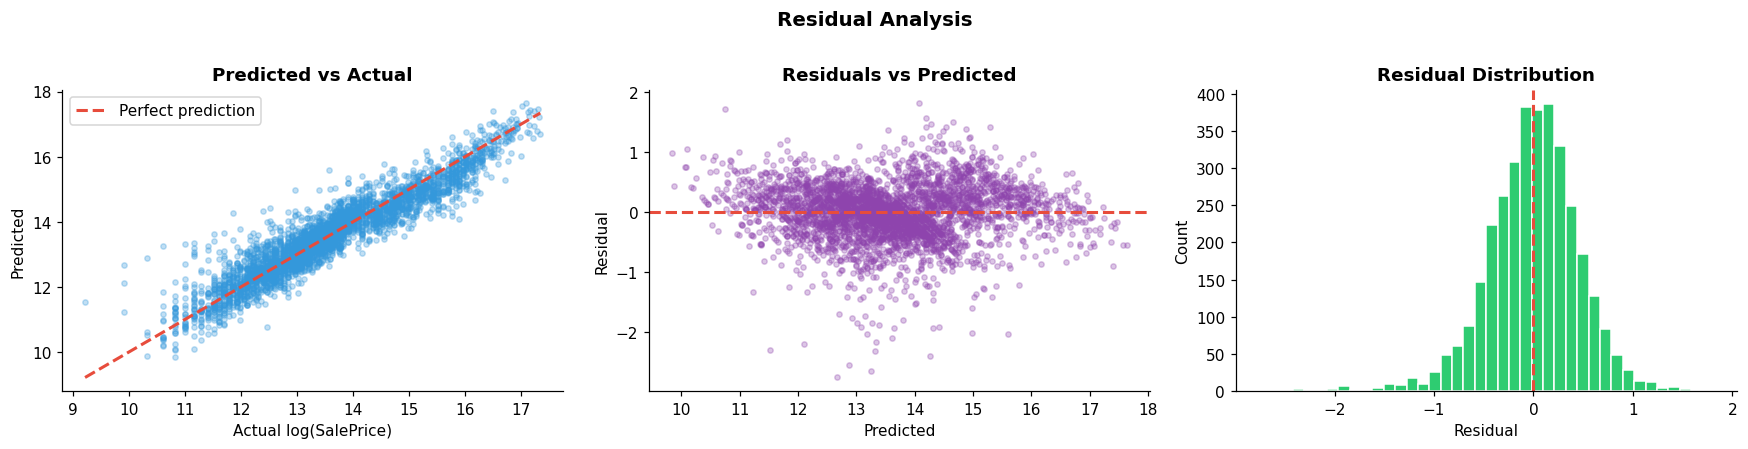

In [ ]:
# Residual analysis plots
y_pred_log = pipe_lr.predict(X_test)
residuals  = y_test - y_pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.scatter(y_test, y_pred_log, alpha=0.3, s=12, color='#3498db')
mn, mx = y_test.min(), y_test.max()
ax.plot([mn,mx],[mn,mx], color='#e74c3c', lw=2, ls='--', label='Perfect prediction')
ax.set_xlabel('Actual log(SalePrice)'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual', fontweight='bold'); ax.legend()

ax = axes[1]
ax.scatter(y_pred_log, residuals, alpha=0.3, s=12, color='#8e44ad')
ax.axhline(0, color='#e74c3c', lw=2, ls='--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted', fontweight='bold')

ax = axes[2]
ax.hist(residuals, bins=40, color='#2ecc71', edgecolor='white')
ax.axvline(0, color='#e74c3c', lw=2, ls='--')
ax.set_xlabel('Residual'); ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### Feature coefficients

Extract and visualize the top feature coefficients from the fitted linear model to understand which features drive the price up or down.


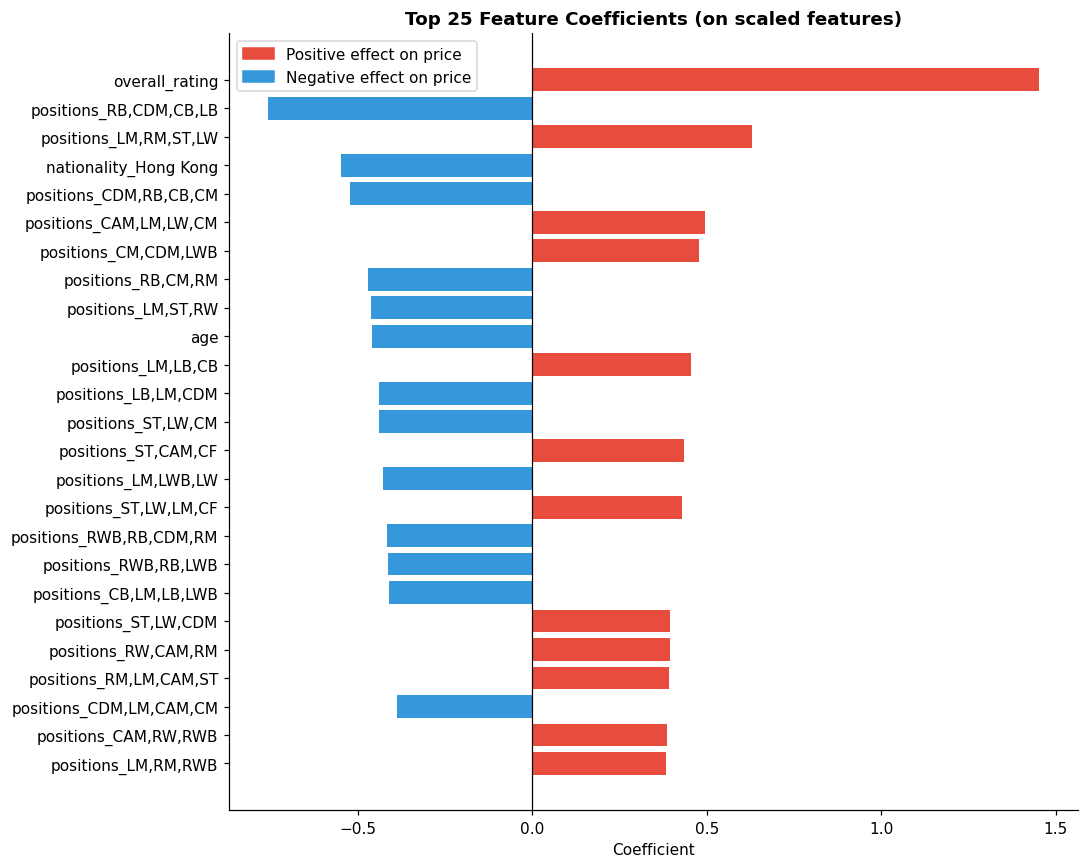

In [ ]:
# Top feature coefficients
try:
    model_step = pipe_lr.named_steps['model']
    prep_step  = pipe_lr.named_steps['preprocessor']

    num_names  = NUM_COLS
    ord_names  = ORDINAL_COLS
    ohe_step   = prep_step.named_transformers_['ohe'].named_steps['onehot']
    ohe_names  = list(ohe_step.get_feature_names_out(OHE_COLS))
    all_names  = num_names + ord_names + ohe_names

    coef_df = (pd.DataFrame({'Feature': all_names, 'Coefficient': model_step.coef_})
                 .sort_values('Coefficient', key=abs, ascending=False)
                 .head(25))

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_c = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
    ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors_c[::-1])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title('Top 25 Feature Coefficients (on scaled features)', fontweight='bold')
    ax.set_xlabel('Coefficient')
    red_p  = mpatches.Patch(color='#e74c3c', label='Positive effect on price')
    blue_p = mpatches.Patch(color='#3498db', label='Negative effect on price')
    ax.legend(handles=[red_p, blue_p])
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Could not extract coefficients: {e}')

### Sample predictions

Compare predicted vs. actual values for a few individual observations from the test set.


In [ ]:
def predict_one(index: int):
    """Take one row from X_test and compare prediction vs actual."""
    obs       = X_test.iloc[[index]]
    actual    = np.expm1(y_test[index])
    predicted = np.expm1(pipe_lr.predict(obs)[0])
    err_pct   = abs(actual - predicted) / actual * 100
    print(f'Observation #{index}')
    print(f'  Actual value   : €{actual:>12,.0f}')
    print(f'  Predicted value: €{predicted:>12,.0f}')
    print(f'  Absolute value     : €{abs(actual-predicted):>12,.0f}  ({err_pct:.1f}%)')
    print('-'*45)
    return predicted

for idx in [0, 10, 50, 100]:
    predict_one(idx)

Observation #0
  Actual value   : €     280,000
  Predicted value: €     327,814
  Absolute value     : €      47,814  (17.1%)
---------------------------------------------
Observation #10
  Actual value   : €     750,000
  Predicted value: €     804,832
  Absolute value     : €      54,832  (7.3%)
---------------------------------------------
Observation #50
  Actual value   : €     240,000
  Predicted value: €     238,708
  Absolute value     : €       1,292  (0.5%)
---------------------------------------------
Observation #100
  Actual value   : €  10,500,000
  Predicted value: €   9,449,447
  Absolute value     : €   1,050,553  (10.0%)
---------------------------------------------


# Data Preprocessing

## Objective

Before training the machine learning model, the dataset needs to be prepared.

In this step, we will define the target variable, split the data into features and target, transform different types of features, and create a preprocessing pipeline.

### Preprocessing Steps

1. Define the target variable.
2. Split the dataset into features (`X`) and target (`y`).
3. Split the data into training and testing sets.
4. Identify numerical and categorical features.
5. Encode categorical features.
6. Scale numerical features.
7. Create a preprocessing pipeline.
8. Verify the preprocessing results.


### Define features and target

Split the cleaned dataset into the feature matrix `X` and the target `y`.


In [ ]:
target = "value_euro"
X = df.drop(
    columns=[target]
)


In [ ]:
y = np.log1p(
    df["value_euro"]
)

In [ ]:
X.shape, y.shape

((17699, 45), (17699,))

### Train/test split

Split the data into training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(14159, 45)
(3540, 45)
(14159,)
(3540,)


### Identify feature types

Separate the numeric and categorical columns so each can be preprocessed appropriately.


In [ ]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns


numeric_features

Index(['age', 'height_cm', 'weight_kgs', 'overall_rating', 'potential',
       'wage_euro', 'international_reputation(1-5)', 'weak_foot(1-5)',
       'skill_moves(1-5)', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'composure', 'marking', 'standing_tackle',
       'sliding_tackle', 'potential_gap'],
      dtype='object')

In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns


categorical_features

Index(['positions', 'nationality', 'preferred_foot', 'body_type', 'age_group',
       'player_level'],
      dtype='object')

### Preprocessing imports


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Build the preprocessing pipeline

Scale numeric features with `StandardScaler` and one-hot encode categorical features, combined via a `ColumnTransformer`.


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Apply preprocessing

Fit the preprocessor on the training data and transform both the train and test sets.


In [ ]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_train_prepared.shape

(14159, 995)

In [ ]:
X_test_prepared = preprocessor.transform(X_test)

In [ ]:
X_train_prepared.shape, X_test_prepared.shape

((14159, 995), (3540, 995))

# Baseline Model

## Objective

The goal of this step is to create simple baseline models that will provide a reference point for future improvements.

Before building complex machine learning models, we need to understand how well simple approaches perform on the dataset.

### Baseline Models

The following models will be evaluated:

- **Linear Regression** — a basic machine learning model that estimates linear relationships between features and the target variable.

### Evaluation Metrics

The models will be evaluated using regression metrics:

- **MAE (Mean Absolute Error)** — measures the average absolute difference between predictions and actual values.
- **RMSE (Root Mean Squared Error)** — measures prediction errors with higher penalty for large mistakes.
- **R² Score** — shows how much variance in the target variable is explained by the model.

In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Build the baseline pipeline

Combine the preprocessor with a plain Linear Regression model.


In [ ]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

### Fit the baseline model


In [ ]:
baseline_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Generate predictions

Predict on the test set and convert both predictions and true values back from log scale to the original euro scale.


In [ ]:
y_pred_log = baseline_model.predict(X_test)

y_pred = np.expm1(y_pred_log)

y_test_original = np.expm1(y_test)

### Evaluate the baseline model

Compute MAE, RMSE, and R2 on the test set.


In [ ]:
mae = mean_absolute_error(
    y_test_original,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred
    )
)

r2 = r2_score(
    y_test_original,
    y_pred
)

print(f'MAE: {round(mae, 2)} || RMSE: {rmse.round(2)} || R2: {round(r2, 4)}')

MAE: 496764.03 || RMSE: 2647613.62 || R2: 0.7886


### Reusable evaluation function

Wrap the evaluation logic (log-scale to original-scale conversion + metrics) into a reusable function.


In [ ]:
def evaluate_model(model, X_test, y_test_log):
    
    predictions_log = model.predict(X_test)
    
    predictions = np.expm1(predictions_log)
    y_test = np.expm1(y_test_log)
    
    
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    
    print(f"MAE: {mae:,.2f} €")
    print(f"RMSE: {rmse:,.2f} €")
    print(f"R2: {r2:.4f}")
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

MAE: 496,764.03 €
RMSE: 2,647,613.62 €
R2: 0.7886


### Actual vs. predicted values

Visualize how closely the predicted market values match the actual ones.


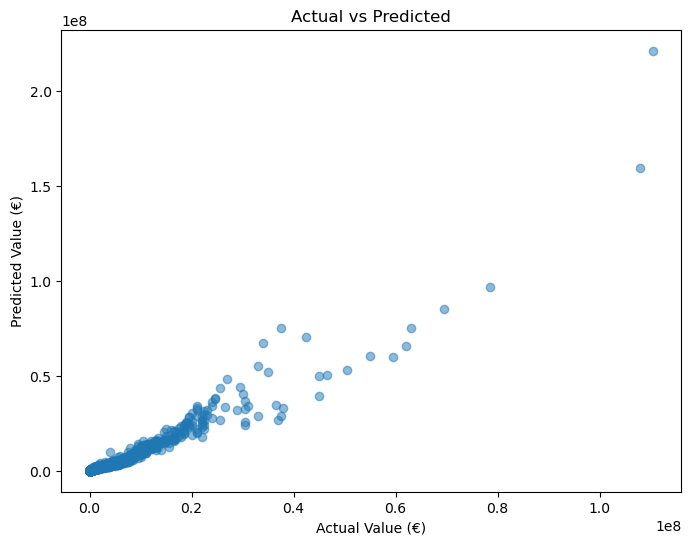

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_original,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Value (€)")
plt.ylabel("Predicted Value (€)")
plt.title("Actual vs Predicted")

plt.show()

### Results summary

Collect the baseline model's metrics into a single results table for easy comparison with future models.


In [ ]:
results = pd.DataFrame(
    {
        "Model": ["Linear Regression"],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    }
)

results

,Model,MAE,RMSE,R2
0,Linear Regression,496764.027608,2.647614e+06,0.788585
